In [ ]:
import torch

print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))


PyTorch CUDA available: True
Device name: Tesla T4


In [ ]:
# Cell 1: Check GPU
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

# Cell 2: Install packages
!pip install --upgrade diffusers transformers accelerate safetensors huggingface_hub
!pip install pillow matplotlib

# Cell 3: Hugging Face Login
from huggingface_hub import notebook_login
notebook_login()

# Cell 4: DeepSeek R1 text-to-image demo
from diffusers import StableDiffusionPipeline
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"

# Using Stable Diffusion as a proxy for DeepSeek R1 in Colab
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

import torch

# Make a random generator for GPU
generator = torch.Generator(device=device).manual_seed(torch.seed())

prompt = "A beautiful classroom listening to an AI lecture"
image = pipe(prompt, generator=generator, num_inference_steps=10, negative_prompt).images[0]
image.show()


CUDA available: True
Device name: Tesla T4


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

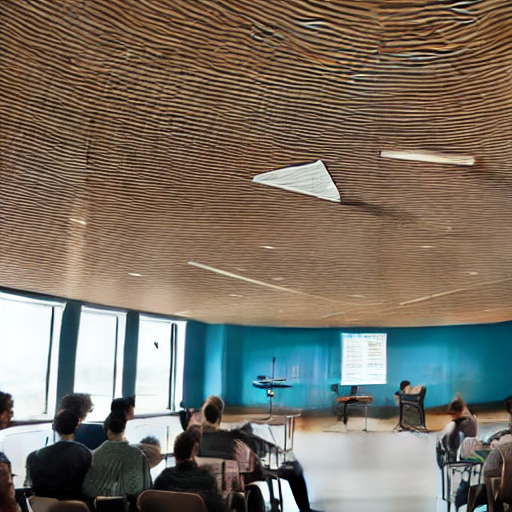

In [ ]:
from IPython.display import display
image.save("deepseek_demo.png")
display(image)